In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, recall_score, precision_score
)
from sklearn.utils.class_weight import compute_class_weight

from transformers import PatchTSTConfig, PatchTSTForClassification

import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
data0 = pd.read_csv('../../../data/labeled_dataset.csv')
print(data0.columns)
data1 = pd.read_csv('../../../data/master_data.csv')
print(data1.columns)
data = pd.read_csv('../../../data/multivariate_gmm_labeled_dataset.csv', dtype=str)
print(data.columns)

df = data.sort_values("Date")

df.columns = df.columns.str.strip()

df['regime'] = df['regime'].str.lower().str.strip()
df['regime'] = df['regime'].map({"bear": 0, "bull": 1})

df.replace([np.inf, -np.inf], np.nan, inplace=True)

df.ffill(inplace=True)

df.dropna(inplace=True)

df = df.astype(float, errors="ignore")

print("NaN:", df.isna().sum().sum())


features = [
    'Return', 'Return_5d', 'Return_20d', 'Return_Smooth',
    
    'RSI_14',
    'MACD_Hist', 'MACD_Line', 'MACD_Signal',
    
    'VIX', 'VIX_Change', 'VIX_Change_5d',
    
    'SPY Volume', 
    'Drawdown',
    
    'GDP_YoY', 'Core_Inflation_YoY', 'M2_YoY', 'Unemployment',
    
    'Consumer_Sentiment', 'Consumer_Sentiment_ZScore'
]

label_col = "regime"

OUTPUT_DIR = Path("../../../reports/trained_patchtst/results_gmm")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = OUTPUT_DIR / "best_patchtst.pth"
TRAINING_HISTORY_PATH = OUTPUT_DIR / "training_history.csv"
TEST_METRICS_PATH = OUTPUT_DIR / "test_metrics.csv"
CONFUSION_MATRIX_PATH = OUTPUT_DIR / "confusion_matrix.csv"
PREDICTIONS_PATH = OUTPUT_DIR / "predictions.csv"
PREDICTION_PLOT_PATH = OUTPUT_DIR / "prediction_visualisation.png"
THRESHOLD_PATH = OUTPUT_DIR / "selected_threshold.txt"

Index(['Date', 'GSPC', 'VIX', 'SPY Volume', 'GDP', 'Core_Inflation',
       'Unemployment', 'M2', 'Return', 'Return_5d', 'Return_20d',
       'Return_Smooth', 'RSI_14', 'MACD_Line', 'MACD_Signal', 'MACD_Hist',
       'year', 'quarter', 'GDP_YoY', 'month', 'Core_Inflation_YoY', 'M2_YoY',
       'Peak', 'Drawdown', 'VIX_Change', 'VIX_Change_5d', 'regime', 'segment'],
      dtype='object')
Index(['Date', 'GSPC', 'VIX', 'SPY Volume', 'Gold', 'Oil', 'GDP',
       'Core_Inflation', 'Unemployment', 'M2', 'Sentiment', 'Return',
       'Return_5d', 'Return_20d', 'Return_Smooth', 'RSI_14', 'MACD_Line',
       'MACD_Signal', 'MACD_Hist', 'GDP_YoY', 'Core_Inflation_YoY', 'M2_YoY',
       'Peak', 'Drawdown', 'VIX_Change', 'VIX_Change_5d', 'Regime'],
      dtype='object')
Index(['Date', 'GSPC', 'VIX', 'SPY Volume', 'GDP', 'Core_Inflation',
       'Unemployment', 'M2', 'Return', 'Return_5d', 'Return_20d',
       'Return_Smooth', 'RSI_14', 'MACD_Line', 'MACD_Signal', 'MACD_Hist',
       'year', 'quart

In [3]:
n = len(df)

train_end = int(n*0.7)
val_end = int(n*0.8)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

scaler = RobustScaler()

train_X = scaler.fit_transform(train_df[features])
val_X = scaler.transform(val_df[features])
test_X = scaler.transform(test_df[features])

train_y = train_df[label_col].values
val_y = val_df[label_col].values
test_y = test_df[label_col].values

train_X = np.clip(train_X, -5, 5)
val_X = np.clip(val_X, -5, 5)
test_X = np.clip(test_X, -5, 5)

In [4]:
# Sliding Window Construction
SEQ_LEN = 192

def create_sequences(X, y, seq_len):

    Xs, ys = [], []

    for i in range(len(X) - seq_len + 1):

        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len-1])

    return np.array(Xs), np.array(ys)

train_X_seq, train_y_seq = create_sequences(train_X, train_y, SEQ_LEN)
val_X_seq, val_y_seq = create_sequences(val_X, val_y, SEQ_LEN)
test_X_seq, test_y_seq = create_sequences(test_X, test_y, SEQ_LEN)


# Dataset & DataLoader
class TimeSeriesDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_loader = DataLoader(
    TimeSeriesDataset(train_X_seq, train_y_seq),
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    TimeSeriesDataset(val_X_seq, val_y_seq),
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    TimeSeriesDataset(test_X_seq, test_y_seq),
    batch_size=64,
    shuffle=False
)
def feature_dropout(X, p=0.1):

    mask = np.random.binomial(1, 1-p, X.shape)

    return X * mask


In [5]:
# PatchTST 
config = PatchTSTConfig(

    num_input_channels=len(features),

    num_targets=2,

    context_length=SEQ_LEN,

    patch_length=12,
    stride=6
)

model = PatchTSTForClassification(config)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0,1]),
    y=train_y
)
class_weights = torch.tensor(weights).float().to(device)

def focal_loss(logits, targets, alpha=class_weights, gamma=2):
    ce_loss = F.cross_entropy(logits, targets, weight=class_weights, reduction='none', label_smoothing=0.05)
    pt = torch.exp(-ce_loss)
    loss = (1-pt)**gamma * ce_loss
    return loss.mean()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=8e-5,
    betas=(0.9, 0.95),
    weight_decay=5e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)


In [6]:
# Training + Early Stopping 
EPOCHS = 100
patience = 10

best_auc = 0
trigger = 0
training_history = []

for epoch in range(EPOCHS):

    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = feature_dropout(X_batch.numpy(), 0.1)
        X_batch = torch.tensor(X_batch, dtype=torch.float32).to(device)

        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(past_values=X_batch)
        logits = outputs.prediction_logits

        loss = focal_loss(logits, y_batch, gamma=2)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)

    # ===== Validation =====

    model.eval()

    val_probs = []
    val_labels = []

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)

            outputs = model(past_values=X_batch)

            logits = outputs.prediction_logits

            probs = torch.softmax(logits, dim=1)[:,1]

            val_probs.extend(probs.cpu().numpy())
            val_labels.extend(y_batch.numpy())

    auc = roc_auc_score(val_labels, val_probs)

    print(f"Epoch {epoch+1} Loss {train_loss:.4f} Val AUC {auc:.4f}")
    training_history.append({"epoch": epoch + 1, "train_loss": train_loss, "val_auc": auc})

    scheduler.step(auc)

    # ===== Early Stop =====

    if auc > best_auc:

        best_auc = auc
        trigger = 0

        torch.save(model.state_dict(), MODEL_PATH)

        best_val_probs = np.array(val_probs)
        best_val_labels = np.array(val_labels)

    else:

        trigger += 1

        if trigger >= patience:

            print("Early stopping")

            break


thresholds = np.arange(0.05, 0.95, 0.01)

best_score = 0
best_thresh = 0

for t in thresholds:

    preds = (best_val_probs >= t).astype(int)

    recall_bear = recall_score(best_val_labels, preds, pos_label=0)
    recall_bull = recall_score(best_val_labels, preds, pos_label=1)

    score = 0.6 * recall_bear + 0.4 * recall_bull

    if score > best_score:

        best_score = score
        best_thresh = t

print("Best Threshold:", best_thresh)

pd.DataFrame(training_history).to_csv(TRAINING_HISTORY_PATH, index=False)
THRESHOLD_PATH.write_text(str(best_thresh))

Epoch 1 Loss 0.1443 Val AUC 0.7999
Epoch 2 Loss 0.1034 Val AUC 0.8009
Epoch 3 Loss 0.0972 Val AUC 0.8090
Epoch 4 Loss 0.0934 Val AUC 0.8010
Epoch 5 Loss 0.0906 Val AUC 0.8054
Epoch 6 Loss 0.0865 Val AUC 0.7918
Epoch 7 Loss 0.0834 Val AUC 0.8277
Epoch 8 Loss 0.0830 Val AUC 0.8020
Epoch 9 Loss 0.0812 Val AUC 0.7866
Epoch 10 Loss 0.0811 Val AUC 0.7933
Epoch 11 Loss 0.0826 Val AUC 0.7957
Epoch 12 Loss 0.0770 Val AUC 0.7874
Epoch 13 Loss 0.0763 Val AUC 0.8131
Epoch 14 Loss 0.0764 Val AUC 0.7932
Epoch 15 Loss 0.0756 Val AUC 0.7782
Epoch 16 Loss 0.0749 Val AUC 0.7898
Epoch 17 Loss 0.0723 Val AUC 0.8024
Early stopping
Best Threshold: 0.7700000000000001


18

In [7]:
#Test Evaluation
model.load_state_dict(torch.load(MODEL_PATH))

model.eval()

test_probs = []
test_labels = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(past_values=X_batch)

        logits = outputs.prediction_logits

        probs = torch.softmax(logits, dim=1)[:,1]

        test_probs.extend(probs.cpu().numpy())
        test_labels.extend(y_batch.numpy())

test_probs = np.array(test_probs)

test_preds = (test_probs >= best_thresh).astype(int)
# Metrics
accuracy = accuracy_score(test_labels, test_preds)

f1 = f1_score(test_labels, test_preds, average="macro")

precision = precision_score(test_labels, test_preds)

recall = recall_score(test_labels, test_preds) 

roc_auc = roc_auc_score(test_labels, test_probs)

cm = confusion_matrix(test_labels, test_preds)

print("===== Test Metrics =====")

print("Accuracy:", accuracy)

print("F1-score:", f1)

print("Precision:", precision)

print("Recall:", recall)

print("ROC-AUC:", roc_auc)

print("Confusion Matrix:")

print(cm)

test_metrics = pd.DataFrame([
    {
        "accuracy": accuracy,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "roc_auc": roc_auc,
        "threshold": best_thresh,
    }
])
test_metrics.to_csv(TEST_METRICS_PATH, index=False)

pd.DataFrame(cm, index=["actual_bear", "actual_bull"], columns=["pred_bear", "pred_bull"]).to_csv(CONFUSION_MATRIX_PATH)


===== Test Metrics =====
Accuracy: 0.6907801418439716
F1-score: 0.6716902536715621
Precision: 0.728735632183908
Recall: 0.49921259842519683
ROC-AUC: 0.7870500381000761
Confusion Matrix:
[[657 118]
 [318 317]]


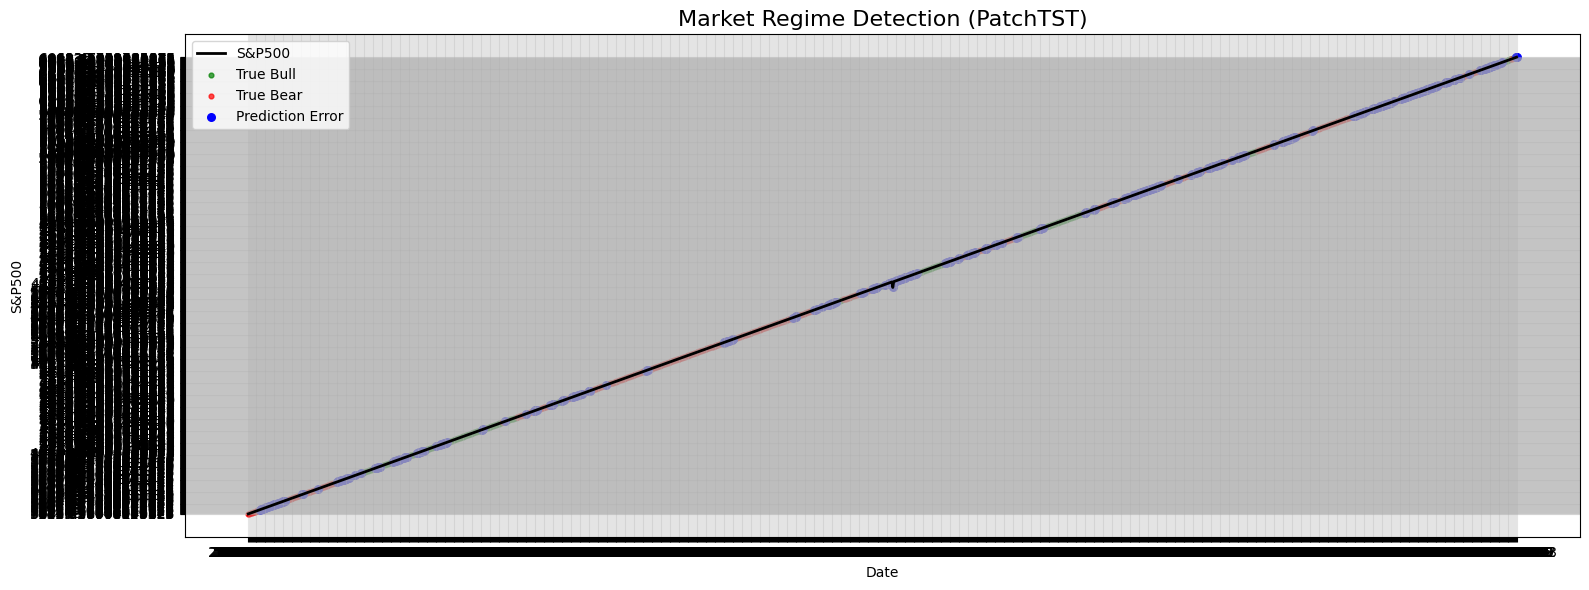

In [8]:
test_dates = test_df["Date"].values
sp500_price = test_df["GSPC"].values

test_dates = test_dates[SEQ_LEN-1:]
sp500_price = sp500_price[SEQ_LEN-1:]

test_labels = np.array(test_labels)
test_preds = np.array(test_preds)

min_len = min(len(test_dates), len(test_labels))

test_dates = test_dates[:min_len]
sp500_price = sp500_price[:min_len]
test_labels = test_labels[:min_len]
test_preds = test_preds[:min_len]

plt.figure(figsize=(16,6))

# SP500
plt.plot(test_dates, sp500_price, color="black", linewidth=2, label="S&P500")

# True Bull
bull_idx = test_labels == 1
plt.scatter(
    test_dates[bull_idx],
    sp500_price[bull_idx],
    color="green",
    s=12,
    alpha=0.7,
    label="True Bull"
)

# True Bear
bear_idx = test_labels == 0
plt.scatter(
    test_dates[bear_idx],
    sp500_price[bear_idx],
    color="red",
    s=12,
    alpha=0.7,
    label="True Bear"
)

# Prediction Errors
error_idx = test_labels != test_preds

plt.scatter(
    test_dates[error_idx],
    sp500_price[error_idx],
    color="blue",
    s=30,
    label="Prediction Error"
)

plt.title("Market Regime Detection (PatchTST)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("S&P500")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PREDICTION_PLOT_PATH, dpi=180, bbox_inches="tight")
plt.show()

predictions = pd.DataFrame({
    "Date": test_dates,
    "GSPC": sp500_price,
    "y_true": test_labels,
    "y_pred": test_preds,
    "y_pred_prob": test_probs[:min_len],
})
predictions.to_csv(PREDICTIONS_PATH, index=False)